## LangChain overview
### Agent = Model + Harness.
LangChain provides create_agent: a minimal, highly configurable harness. The harness is everything around the model loop: the prompt, the tools, and any middleware that shapes behavior. Start with the primitives and compose exactly what your use case needs. Supports OpenAI, Anthropic, Google, and more.

Docs - [Langchain_model](https://docs.langchain.com/oss/python/langchain/models)


In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
open_router_key = os.getenv("OPENROUTER_API_KEY")


In [5]:
from rich import print

In [6]:
from openai import OpenAI

client = OpenAI()

response = client.responses.create(
    model="gpt-5",
    input="Explain what an AI agent is in one sentence."
)

print(response.output_text)

An AI agent is a system that perceives its environment, makes decisions, and takes actions autonomously to achieve 
specified goals.

In [19]:
from langchain.agents import create_agent

def get_weather(city: str) -> str:
    """Get weather for a given city."""
    return f"It's always sunny in {city}!"

agent = create_agent(
    model="openrouter:nvidia/nemotron-3-ultra-550b-a55b:free",
    tools=[get_weather],
    system_prompt="You are a helpful assistant",
)

result = agent.invoke(
    {"messages": [{"role": "user", "content": "What's the weather in San Francisco?"}]}
)
print(result["messages"][-1].content_blocks)

[
    {
        'type': 'reasoning',
        'reasoning': 'The weather tool returned a result: "It\'s always sunny in San Francisco!" I\'ll relay this 
to the user.'
    },
    {'type': 'text', 'text': 'The weather in San Francisco is always sunny! ☀️'}
]

## CORE COMPONENTS
- Model
- Tools
- System Prompt
- Structured Output
- Agent State

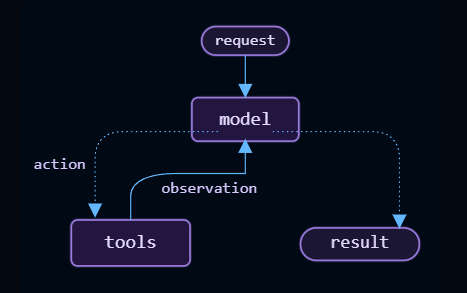

## MODELS
LLMs are powerful AI tools that can interpret and generate text like humans. They’re versatile enough to write content, translate languages, summarize, and answer questions without needing specialized training for each task.

### Initialize a model
The easiest way to get started with a standalone model in LangChain is to use init_chat_model to initialize one from a chat model provider of your choice (examples below):

In [ ]:
from langchain.chat_models import init_chat_model


In [21]:
openai_model = init_chat_model("openai:gpt-5-mini")
openrouter_model = init_chat_model("openrouter:nvidia/nemotron-3-ultra-550b-a55b:free")

In [22]:
response = openrouter_model.invoke("In one line, tell me what is Langchain?")

In [23]:
print(response.content)

LangChain is an open-source framework that simplifies building applications powered by large language models (LLMs)
by providing modular components and chains for prompt management, memory, tool integration, and data retrieval.

In [24]:
chunks = []
full_message = None
for chunk in openai_model.stream("Write one short sentence about the ocean."):
    chunks.append(chunk)
    print(repr(chunk.text), " <- chunk type:", type(chunk).__name__)
    full_message = chunk if full_message is None else full_message + chunk

print()
print("Reconstructed full message:", full_message.content)


''  <- chunk type: AIMessageChunk

'The'  <- chunk type: AIMessageChunk

' ocean'  <- chunk type: AIMessageChunk

' is'  <- chunk type: AIMessageChunk

' vast'  <- chunk type: AIMessageChunk

...

'.'  <- chunk type: AIMessageChunk

''  <- chunk type: AIMessageChunk

''  <- chunk type: AIMessageChunk

''  <- chunk type: AIMessageChunk

Reconstructed full message: The ocean is vast, deep, and full of life.

In [26]:
from langchain_core.messages import SystemMessage,HumanMessage

msg = [
    SystemMessage(content="You are a gen z kid which use genz slang language"),
    HumanMessage(content="What is the Capital of Australia")
]
response = openrouter_model.invoke(msg)
print(response)

AIMessage(
    content="It's **Canberra**, bestie. 🇦🇺 No cap, everyone thinks it's Sydney or Melbourne, but Canberra is the 
actual main character.",
    additional_kwargs={
        'reasoning_content': 'The user is asking for the capital of Australia.\nI need to answer correctly but 
using Gen Z slang.',
        'reasoning_details': [
            {
                'type': 'reasoning.text',
                'format': 'unknown',
                'index': 0,
                'text': 'The user is asking for the capital of Australia.\nI need to answer correctly but using Gen
Z slang.'
            }
        ]
    },
    response_metadata={
        'model_name': 'nvidia/nemotron-3-ultra-550b-a55b:free',
        'id': 'gen-1789137944-yrX0WknzpHqAhrX4TIE3',
        'created': 1789137944,
        'object': 'chat.completion',
        'finish_reason': 'stop',
        'logprobs': None,
        'model_provider': 'openrouter',
        'cost': 0.0,
        'cost_details': {
            'upstream_inference_completions_cost': 0.0,
            'upstream_inference_prompt_cost': 0.0,
            'upstream_inference_cost': 0.0
        }
    },
    id='lc_run--01a090ee-7a02-7f20-a617-af965f1d7998-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 35,
        'output_tokens': 59,
        'total_tokens': 94,
        'input_token_details': {'cache_read': 0, 'cache_creation': 0},
        'output_token_details': {'reasoning': 26}
    }
)

In [27]:
response.usage_metadata

{'input_tokens': 35,
 'output_tokens': 59,
 'total_tokens': 94,
 'input_token_details': {'cache_read': 0, 'cache_creation': 0},
 'output_token_details': {'reasoning': 26}}

In [28]:
from langchain_core.messages import HumanMessage,SystemMessage,AIMessage



In [30]:
import os
from langchain.chat_models import init_chat_model



model = init_chat_model(
    "openrouter/free",  # Automatic but for free
    model_provider="openrouter",
)

response = model.invoke("Hello Which model are you ?")

In [31]:

ai_msg = AIMessage("I'd be happy to help you with that question!")
messages = [
    SystemMessage("You are a helpful assistant"),
    HumanMessage("Can you help me?"),
    ai_msg,
    HumanMessage("Great! What's 2+2?"),
]
response = model.invoke(messages)
print(response.content)

2+2 equals 4!

## Key Methods 
- *Invoke* - The most straightforward way to call a model is to use invoke() with a single message or a list of messages.
- *Stream* - Most models can stream their output content while it is being generated. By displaying output progressively, streaming significantly improves user experience, particularly for longer responses.
- *Batch* - Batching a collection of independent requests to a model can significantly improve performance and reduce costs, as the processing can be done in parallel:
Batch


In [ ]:
model = init_chat_model("openrouter:inclusionai/ling-3.0-flash-sante:free")

In [37]:
chunks = []
full_message = None

In [ ]:
import time
# Using Stream
for chunk in openai_model.stream("Write a long sentence about how AI Agents work"):
  chunks.append(chunk)
  print(repr(chunk.text),type(chunk))
  full_message = chunk if full_message is None else full_message + chunk
  time.sleep(1)

print()
print("Reconstructed full message:", full_message.content)


In [39]:
q1 = 'hi, how are you ?'
q2 = 'tell about AI in less than 100 words?'
q3 = 'Explain agents in 30 words ?'

In [ ]:
responses = model.batch([   # using batch
    q1,
    q2,
    q3
])

In [41]:
for response in responses:
  print(response)

AIMessage(
    content="Hi! I'm doing well, thank you for asking. I'm here and ready to help you with whatever you need. How 
can I assist you today? 😊",
    additional_kwargs={
        'reasoning_content': 'Hmm, the user greeted me with a casual "hi, how are you?" This is a friendly opening,
so I should respond in kind while staying professional. \n\nI can acknowledge the greeting and ask how I can help. 
Keeping it open-ended gives the user flexibility to steer the conversation. \n\nNo need to overcomplicate this—just
a warm but concise reply that invites further interaction.',
        'reasoning_details': [
            {
                'type': 'reasoning.text',
                'format': 'unknown',
                'index': 0,
                'text': 'Hmm, the user greeted me with a casual "hi, how are you?" This is a friendly opening, so I
should respond in kind while staying professional. \n\nI can acknowledge the greeting and ask how I can help. 
Keeping it open-ended gives the user flexibility to steer the conversation. \n\nNo need to overcomplicate this—just
a warm but concise reply that invites further interaction.'
            }
        ]
    },
    response_metadata={
        'model_name': 'inclusionai/ling-3.0-flash-sante:free',
        'id': 'gen-1789146145-0KsflCKFMORfFcL90b6q',
        'created': 1789146145,
        'object': 'chat.completion',
        'finish_reason': 'stop',
        'logprobs': None,
        'model_provider': 'openrouter',
        'cost': 0.0,
        'cost_details': {
            'upstream_inference_completions_cost': 0.0,
            'upstream_inference_prompt_cost': 0.0,
            'upstream_inference_cost': 0.0
        }
    },
    id='lc_run--01a0916b-9d08-7800-8e02-f8878985081e-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 26,
        'output_tokens': 118,
        'total_tokens': 144,
        'input_token_details': {'cache_read': 0, 'cache_creation': 0},
        'output_token_details': {'reasoning': 95}
    }
)

AIMessage(
    content='Artificial Intelligence (AI) refers to machines simulating human intelligence—learning, reasoning, and
problem-solving. Powered by algorithms and data, it enables tasks like image recognition, language translation, and
autonomous driving. From chatbots to medical diagnostics, AI transforms industries by automating processes and 
enhancing decision-making. While offering efficiency and innovation, it raises ethical questions about bias, 
privacy, and job displacement. As a transformative technology, it continues evolving rapidly, shaping how we live 
and work.',
    additional_kwargs={
        'reasoning_content': 'The user wants a brief description of AI in under 100 words. I should be concise, 
accurate, and cover the essence: what it is, how it works, and its impact. Need to count words carefully.\n\nDraft:
"Artificial Intelligence (AI) refers to machines simulating human intelligence—learning, reasoning, and 
problem-solving. Powered by algorithms and data, it enables tasks like image recognition, language translation, and
autonomous driving. From chatbots to medical diagnostics, AI transforms industries by automating processes and 
enhancing decision-making. While offering efficiency and innovation, it raises ethical questions about bias, 
privacy, and job displacement. As a transformative technology, it continues evolving rapidly, shaping how we live 
and work."\n\nWord count: 62 words. Good, under 100. Covers definition, capabilities, applications, and 
implications briefly.',
        'reasoning_details': [
            {
                'type': 'reasoning.text',
                'format': 'unknown',
                'index': 0,
                'text': 'The user wants a brief description of AI in under 100 words. I should be concise, 
accurate, and cover the essence: what it is, how it works, and its impact. Need to count words carefully.\n\nDraft:
"Artificial Intelligence (AI) refers to machines simulating human intelligence—learning, reasoning, and 
problem-solving. Powered by algorithms and data, it enables tasks like image recognition, language translation, and
autonomous driving. From chatbots to medical diagnostics, AI transforms industries by automating processes and 
enhancing decision-making. While offering efficiency and innovation, it raises ethical questions about bias, 
privacy, and job displacement. As a transformative technology, it continues evolving rapidly, shaping how we live 
and work."\n\nWord count: 62 words. Good, under 100. Covers definition, capabilities, applications, and 
implications briefly.'
            }
        ]
    },
    response_metadata={
        'model_name': 'inclusionai/ling-3.0-flash-sante:free',
        'id': 'gen-1789146145-r4zkJaxnPtmp007SNuk0',
        'created': 1789146145,
        'object': 'chat.completion',
        'finish_reason': 'stop',
        'logprobs': None,
        'model_provider': 'openrouter',
        'cost': 0.0,
        'cost_details': {
            'upstream_inference_completions_cost': 0.0,
            'upstream_inference_prompt_cost': 0.0,
            'upstream_inference_cost': 0.0
        }
    },
    id='lc_run--01a0916b-9d23-7d22-b898-99b6bc429542-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 32,
        'output_tokens': 270,
        'total_tokens': 302,
        'input_token_details': {'cache_read': 0, 'cache_creation': 0},
        'output_token_details': {'reasoning': 220}
    }
)

AIMessage(
    content='Agents are autonomous programs that perceive their environment, make decisions, and take actions to 
achieve goals, either independently or on behalf of users.',
    additional_kwargs={
        'reasoning_content': 'The user asks to explain "agents" in 30 words. This is extremely broad — "agents" 
could mean software agents, AI agents, game agents, travel agents, literary agents, etc. Given current context, 
likely AI/software agents. I need to define concisely within 30 words.\n\nDraft: "Agents are autonomous programs 
that perceive their environment, make decisions, and take actions to achieve goals, either independently or on 
behalf of users."\n\nCount: Agents(1) are(2) autonomous(3) programs(4) that(5) perceive(6) their(7) environment(8) 
make(9) decisions(10) and(11) take(12) actions(13) to(14) achieve(15) goals(16) either(17) independently(18) or(19)
on(20) behalf(21) of(22) users(23). = 23 words. Good, under 30.\n\nI could add "AI" for clarity but it\'s optional.
Keep it.',
        'reasoning_details': [
            {
                'type': 'reasoning.text',
                'format': 'unknown',
                'index': 0,
                'text': 'The user asks to explain "agents" in 30 words. This is extremely broad — "agents" could 
mean software agents, AI agents, game agents, travel agents, literary agents, etc. Given current context, likely 
AI/software agents. I need to define concisely within 30 words.\n\nDraft: "Agents are autonomous programs that 
perceive their environment, make decisions, and take actions to achieve goals, either independently or on behalf of
users."\n\nCount: Agents(1) are(2) autonomous(3) programs(4) that(5) perceive(6) their(7) environment(8) make(9) 
decisions(10) and(11) take(12) actions(13) to(14) achieve(15) goals(16) either(17) independently(18) or(19) on(20) 
behalf(21) of(22) users(23). = 23 words. Good, under 30.\n\nI could add "AI" for clarity but it\'s optional. Keep 
it.'
            }
        ]
    },
    response_metadata={
        'model_name': 'inclusionai/ling-3.0-flash-sante:free',
        'id': 'gen-1789146145-hHvvHZLPirxvFAMt271g',
        'created': 1789146145,
        'object': 'chat.completion',
        'finish_reason': 'stop',
        'logprobs': None,
        'model_provider': 'openrouter',
        'cost': 0.0,
        'cost_details': {
            'upstream_inference_completions_cost': 0.0,
            'upstream_inference_prompt_cost': 0.0,
            'upstream_inference_cost': 0.0
        }
    },
    id='lc_run--01a0916b-9d42-74e1-81cc-b1e34b782fd9-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 28,
        'output_tokens': 265,
        'total_tokens': 293,
        'input_token_details': {'cache_read': 0, 'cache_creation': 0},
        'output_token_details': {'reasoning': 194}
    }
)

## Tools Calling
Models can request to call tools that perform tasks such as fetching data from a database, searching the web, or running code.

In [43]:
def get_weather(location:str) ->str:
  "Get the weather at a location"
  print("I was called from somewhere")
  return f"Sunny in '{location}"

In [42]:
def set_password(new_pass):
    "A tool to set a password"
    return "password changed"

In [44]:
model_with_tools = model.bind_tools([get_weather,set_password])

In [45]:
response = model_with_tools.invoke('set password to admin123')

In [46]:
response.tool_calls

[{'name': 'set_password',
  'args': {'new_pass': 'admin123'},
  'id': 'call_d238512983474baa8e109e4b',
  'type': 'tool_call'}]

## Structured output
Models can be requested to provide their response in a format matching a given schema. This is useful for ensuring the output can be easily parsed and used in subsequent processing. LangChain supports multiple schema types and methods for enforcing structured output.

For this we'll be using pydantic

In [47]:
# Pydantic models provide the richest feature set with field validation, descriptions, and nested structures.
from pydantic import BaseModel,Field

In [ ]:

class Movie(BaseModel):
    """A movie with details."""
    title: str = Field(description="The title of the movie")
    year: int = Field(description="The year the movie was released")
    director: str = Field(description="The director of the movie")
    rating: float = Field(description="The movie's rating out of 10")

model_with_structure = model.with_structured_output(Movie)
response = model_with_structure.invoke("Provide details about the movie Inception")
print(response)  # Movie(title="Inception", year=2010, director="Christopher Nolan", rating=8.8)